<a href="https://colab.research.google.com/github/ojumoolatimi/Stroke-Risk-Model/blob/main/Molecule_Protein_Classification_GBT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline



warnings.filterwarnings("ignore")

In [2]:
!git clone https://github.com/ojumoolatimi/Stroke-Risk-Model.git

Cloning into 'Stroke-Risk-Model'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 15 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 227.29 KiB | 2.23 MiB/s, done.
Resolving deltas: 100% (3/3), done.


## **Data Wrangling**
Before building the model, we need to prepare our data. We define a wrangle function
that handles all preprocessing steps in one place. This includes removing irrelevant
columns like Name and SMILES that cannot be used as numeric features, dropping the
unnamed index column, and allowing an optional index to be set. Wrapping these steps
in a function ensures our pipeline is clean, reusable, and consistent.

In [64]:
def wrangle(url, set_index=None):
    df = pd.read_csv(url)

    # Drop unnecessary columns (always runs)
    df.drop(columns=['Unnamed: 0', 'Name', 'SMILES'], inplace=True)

    # Set index only if provided
    if set_index:
        df = df.set_index(set_index)


    #remove outlier in molecular weight
    mask_max = df['Molecular Weight'] < 1658.950000
    df = df[mask_max]

    #remove outlier in TPSA
    mask_max_TPSA = df['TPSA'] < 208.750000
    df = df[mask_max_TPSA]

    return df

## **Import**
With our wrangle function defined, we load the molecule classification dataset
directly from GitHub. The ChEMBL ID column is set as the index since it serves
as a unique identifier for each molecule rather than a predictive feature.


In [65]:

df = wrangle(
    "https://raw.githubusercontent.com/ojumoolatimi/Stroke-Risk-Model/main/molecule_classification_dataset.csv",
    set_index='ChEMBL ID'
)

df.head()

,Molecular Weight,LogP,HBA,HBD,TPSA,Protein
ChEMBL ID,,,,,,
CHEMBL292323,622.77,7.99,8.0,2.0,86.52,EGFR
CHEMBL304414,562.72,7.97,6.0,2.0,68.06,EGFR
CHEMBL62176,282.37,3.19,2.0,1.0,32.34,EGFR
CHEMBL62701,564.70,6.76,8.0,2.0,93.84,EGFR
CHEMBL137617,357.22,4.54,5.0,2.0,74.56,EGFR


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1419 entries, CHEMBL292323 to CHEMBL4636622
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Molecular Weight  1419 non-null   float64
 1   LogP              1412 non-null   float64
 2   HBA               1412 non-null   float64
 3   HBD               1412 non-null   float64
 4   TPSA              1412 non-null   float64
 5   Protein           1419 non-null   object 
dtypes: float64(5), object(1)
memory usage: 77.6+ KB


In [66]:
df.describe()

,Molecular Weight,LogP,HBA,HBD,TPSA
count,1411.000000,1411.000000,1411.000000,1411.000000,1411.000000
mean,408.958852,3.704656,4.835578,1.221120,58.228972
std,103.021593,1.397004,1.637732,1.283007,26.395599
min,135.170000,-0.290000,1.000000,0.000000,3.240000
25%,345.615000,2.870000,4.000000,0.000000,41.370000
50%,399.490000,3.580000,5.000000,1.000000,54.040000
75%,448.610000,4.300000,6.000000,2.000000,71.880000
max,990.180000,13.320000,14.000000,7.000000,166.170000


# **Data Exploration**

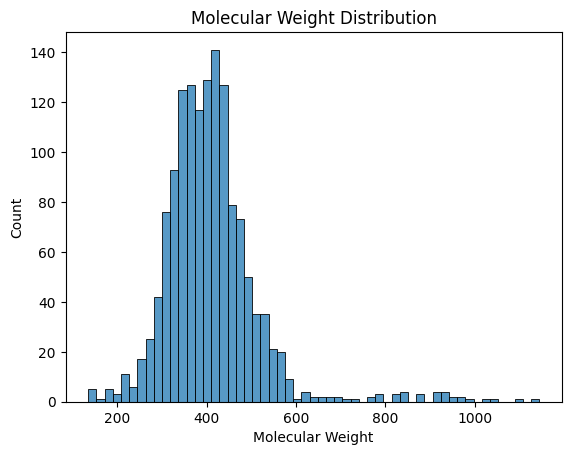

In [58]:
sns.histplot(df['Molecular Weight'])
plt.title('Molecular Weight Distribution')
plt.show()

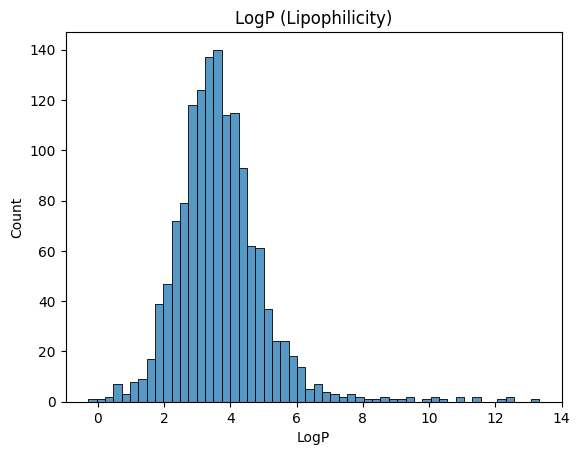

In [60]:
sns.histplot(df['LogP'])
plt.title('LogP (Lipophilicity)')
plt.show()

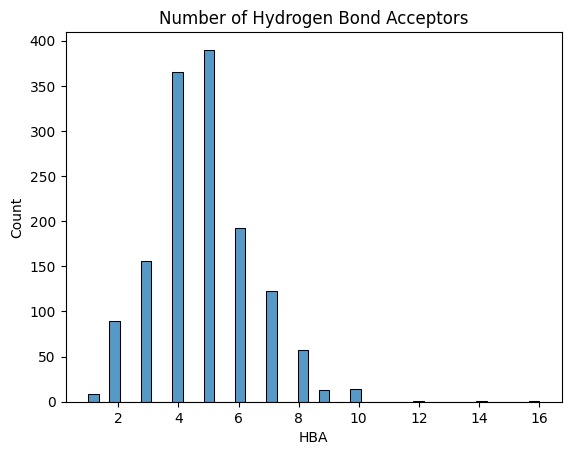

In [61]:
sns.histplot(df['HBA'])
plt.title('Number of Hydrogen Bond Acceptors')
plt.show()

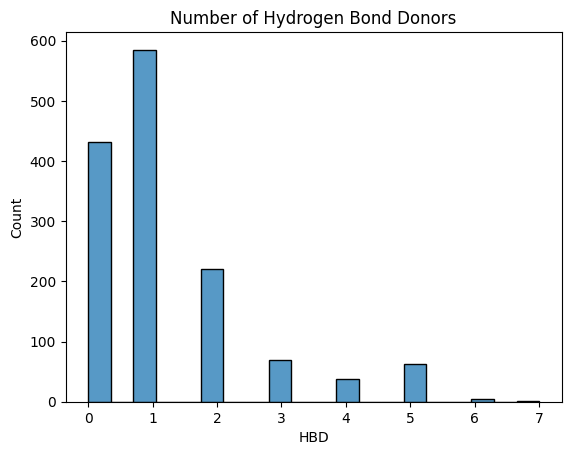

In [62]:
sns.histplot(df['HBD'])
plt.title('Number of Hydrogen Bond Donors')
plt.show()

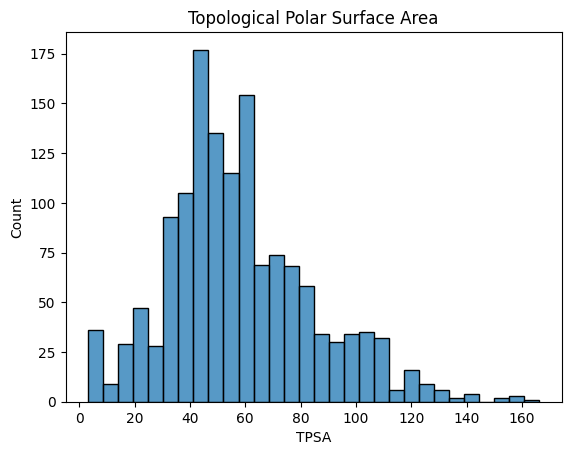

In [67]:
sns.histplot(df['TPSA'])
plt.title('Topological Polar Surface Area')
plt.show()

## **Class Imbalance**
We visualize the distribution of our target variable Protein using a countplot
and print the percentage breakdown of each class to confirm the class imbalance.

Protein
DRD2     89.381153
EGFR      6.399437
HDAC1     4.078762
BACE1     0.140647
Name: proportion, dtype: float64


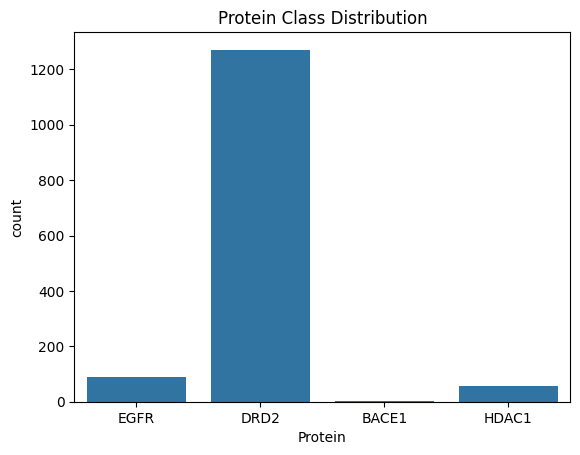

In [6]:
# Target distribution
sns.countplot(data=df, x='Protein')
plt.title('Protein Class Distribution')

# Percentage breakdown
print(df['Protein'].value_counts(normalize=True) * 100)

## **Target Encoding**
We use LabelEncoder to convert our target variable Protein from text labels
into numeric values since machine learning models require numeric inputs.

In [7]:
le = LabelEncoder()
y = le.fit_transform(df['Protein'])

In [8]:
X = df.drop(columns=['Protein'])


In [9]:
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1422, 5)
y shape: (1422,)


## **Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (1137, 5)
y_train shape: (1137,)
X_test shape: (285, 5)
y_test shape: (285,)


## **Resample**
We apply RandomOverSampler to balance our training data by oversampling the
minority classes to match the majority class, then print the new shapes to
confirm the resampling worked correctly.

In [11]:
over_sampling = RandomOverSampler(random_state= 42)
X_train_over, y_train_over = over_sampling.fit_resample(X_train, y_train)
print('X_train_over shape:', X_train_over.shape)
print('y_train_over shape:', y_train_over.shape)

X_train_over shape: (4088, 5)
y_train_over shape: (4088,)


## **Build model**

Before training our model, we establish a baseline accuracy to use as a benchmark.
The baseline represents the accuracy achieved by a naive model that always predicts
the most frequent class in our case DRD2. Any model we build must significantly
outperform this baseline, and more importantly must demonstrate strong recall and
F1 scores on the minority classes EGFR, HDAC1 and BACE1.

In [12]:
# Convert to Series first, then value_counts
acc_baseline = pd.Series(y_train).value_counts(normalize=True).max()
print('Baseline Accuracy:', round(acc_baseline, 4))

Baseline Accuracy: 0.8989


## **Model Pipeline Construction**

In [13]:
clf = make_pipeline(
    SimpleImputer(),
    GradientBoostingClassifier(random_state=42)

)

In [14]:
params = {
    'simpleimputer__strategy': ['mean', 'median'],
    'gradientboostingclassifier__n_estimators': range(100, 600, 100),
    'gradientboostingclassifier__max_depth': range(1, 10),
}

In [16]:
model = GridSearchCV(clf, params, cv=5, n_jobs=-1, verbose=1)

# Fit model to over-sampled training data
model.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                       ('gradientboostingclassifier',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'gradientboostingclassifier__max_depth': range(1, 10),
                         'gradientboostingclassifier__n_estimators': range(100, 600, 100),
                         'simpleimputer__strategy': ['mean', 'median']},
             verbose=1)


get cross-validation results from a hyperparameter search in scikit-learn

In [17]:
pd.DataFrame(model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gradientboostingclassifier__max_depth,param_gradientboostingclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.843229,0.502688,0.017534,0.009169,1,100,mean,"{'gradientboostingclassifier__max_depth': 1, '...",0.911980,0.911980,0.909535,0.908201,0.893513,0.907042,0.006919,90
1,3.194101,0.446886,0.025459,0.009176,1,100,median,"{'gradientboostingclassifier__max_depth': 1, '...",0.914425,0.911980,0.910758,0.914321,0.903305,0.910958,0.004074,89
2,5.262125,1.283426,0.013476,0.001722,1,200,mean,"{'gradientboostingclassifier__max_depth': 1, '...",0.944988,0.933985,0.925428,0.927785,0.922889,0.931015,0.007896,88
3,2.565806,0.119213,0.012068,0.000630,1,200,median,"{'gradientboostingclassifier__max_depth': 1, '...",0.947433,0.933985,0.918093,0.935129,0.922889,0.931506,0.010267,87
4,4.453654,0.784205,0.014659,0.000226,1,300,mean,"{'gradientboostingclassifier__max_depth': 1, '...",0.954768,0.936430,0.930318,0.938800,0.930233,0.938110,0.008984,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,17.619595,0.808480,0.038530,0.000929,9,300,median,"{'gradientboostingclassifier__max_depth': 9, '...",0.993888,0.995110,0.997555,0.993880,0.993880,0.994863,0.001428,13
86,18.522021,0.560839,0.049530,0.018232,9,400,mean,"{'gradientboostingclassifier__max_depth': 9, '...",0.993888,0.995110,0.996333,0.992656,0.993880,0.994373,0.001250,42
87,18.062654,0.686053,0.041607,0.002764,9,400,median,"{'gradientboostingclassifier__max_depth': 9, '...",0.993888,0.995110,0.997555,0.993880,0.993880,0.994863,0.001428,13
88,18.710509,0.887545,0.054635,0.015943,9,500,mean,"{'gradientboostingclassifier__max_depth': 9, '...",0.993888,0.995110,0.996333,0.992656,0.993880,0.994373,0.001250,42


In [68]:
# Extract best hyperparameters
model.best_params_

{'gradientboostingclassifier__max_depth': 5,
 'gradientboostingclassifier__n_estimators': 300,
 'simpleimputer__strategy': 'median'}

In [20]:
y_pred = model.predict(X_test)
y_pred[:10]

array([1, 1, 1, 2, 1, 1, 1, 1, 1, 1])

Actual vs Predicted values test model

In [33]:
y_pred = model.best_estimator_.predict(X_test)
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results_df.head(10)

,Actual,Predicted
0,2,1
1,1,1
2,1,1
3,2,2
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


## **Evaluation**
We evaluate our model by calculating the accuracy score on both the training
and test sets to check how well the model has learned and whether it generalises
to unseen data.

In [69]:
acc_train = model.score(X_train_over, y_train_over)
acc_test = model.score(X_test, y_test)
print("Training Accuracy:", round(acc_train, 4))
print("Validation Accuracy:", round(acc_test, 4))

Training Accuracy: 1.0
Validation Accuracy: 0.9439


              precision    recall  f1-score   support

       BACE1       0.00      0.00      0.00         1
        DRD2       0.97      0.97      0.97       249
        EGFR       0.70      0.74      0.72        19
       HDAC1       0.93      0.81      0.87        16

    accuracy                           0.94       285
   macro avg       0.65      0.63      0.64       285
weighted avg       0.95      0.94      0.95       285



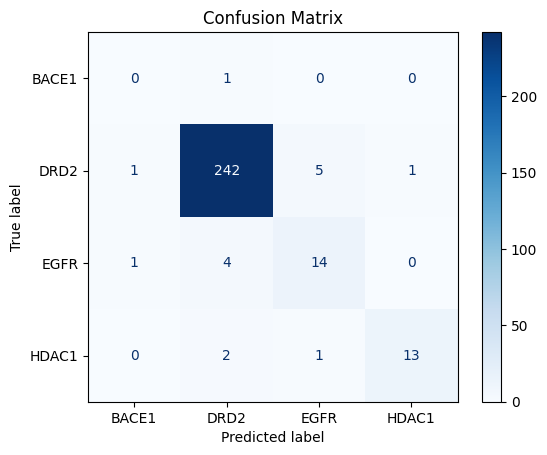

In [70]:


# 5. Classification Report (all of the above per class)
print(classification_report(y_test, y_pred,
      target_names=['BACE1', 'DRD2', 'EGFR', 'HDAC1']))

# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
      display_labels=['BACE1', 'DRD2', 'EGFR', 'HDAC1']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


Here's a full interpretation of my results:

---

## Overall Performance
my model achieved **94% accuracy** which comfortably beats the baseline of ~89%. The **weighted F1 of 0.95** confirms the model is genuinely learning and not just predicting DRD2 every time.

---

## Class by Class Breakdown

**DRD2 — Excellent ✅**
- Precision 0.97, Recall 0.97, F1 0.97
- Out of 249 actual DRD2 molecules, the model correctly identified 242
- The model has learned DRD2's physicochemical signature very well

**HDAC1 — Good ✅**
- Precision 0.81, Recall 0.81, F1 0.87
- Out of 16 actual HDAC1 molecules, 13 were correctly identified
- Strong performance considering only 16 test samples

**EGFR — Fair ⚠️**
- Precision 0.70, Recall 0.74, F1 0.72
- Out of 19 actual EGFR molecules, only 14 were correctly identified
- 4 EGFR molecules were misclassified as DRD2 (visible in confusion matrix)
- The 5 physicochemical features alone struggle to fully separate EGFR from DRD2

**BACE1 — Poor ❌**
- Precision 0.00, Recall 0.00, F1 0.00
- The model completely failed to identify the 1 BACE1 test sample
- This was expected — only 2 BACE1 samples existed in the entire dataset, making it nearly impossible to learn

---

## Confusion Matrix Interpretation

```
- 242/249 DRD2 correctly classified  → model is very strong here
- 14/19  EGFR correctly classified   → 4 misclassified as DRD2
- 13/16  HDAC1 correctly classified  → 2 misclassified as DRD2
- 0/1    BACE1 correctly classified  → predicted as DRD2
```



## **Communication**

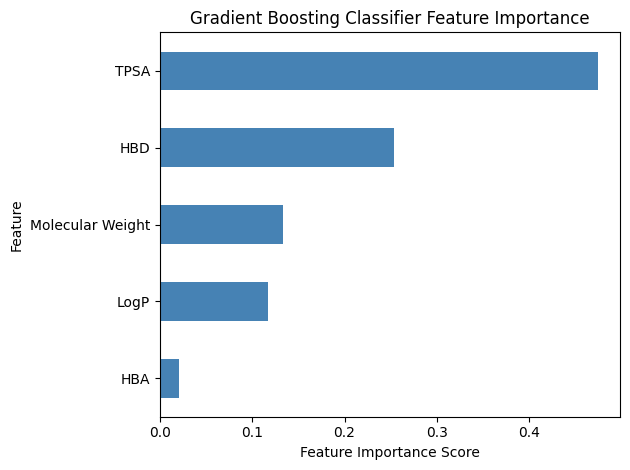

In [72]:
# Get importances
importances = model.best_estimator_.named_steps['gradientboostingclassifier'].feature_importances_

# Feature names (no OneHotEncoder since all features are numeric)
feature_names = X_train.columns

# Create Series
feat_imp = pd.Series(importances, index=feature_names).sort_values()

# Plot
feat_imp.plot(kind='barh', color='steelblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Gradient Boosting Classifier Feature Importance")
plt.tight_layout()
plt.show()



---

| Feature | Importance | Meaning |
|---------|-----------|---------|
| TPSA| 0.45 | Most useful feature |
| HBD | 0.30 | Second most useful |
| Molecular Weight | 0.12 | Moderate contribution |
| LogP | 0.08 | Small contribution |
| HBA | 0.05 | Least useful feature |



Based on the dataset, the aim is:

---

**🎯 Core Aim:**
> **Predict which protein a molecule binds to, based on its physicochemical properties**

This is a **multi-class molecular classification** problem in the field of **drug discovery / cheminformatics**.

---

**In plain terms:**
Given a molecule's properties (size, lipophilicity, polarity etc.), can we automatically predict whether it targets **DRD2, EGFR, HDAC1, or BACE1**?

---

**Why this matters in the real world:**

| Protein | Disease relevance |
|--------|------------------|
| **DRD2** | Schizophrenia, Parkinson's disease |
| **EGFR** | Lung cancer, breast cancer |
| **HDAC1** | Cancer (epigenetic target) |
| **BACE1** | Alzheimer's disease |






**Glossary of Features**

**Molecular Weight**
The mass of a molecule measured in grams per mole (g/mol). Larger molecules are generally harder for the body to absorb. Drugs typically have a molecular weight below 500 g/mol.

**LogP (Lipophilicity)**
A measure of how well a molecule dissolves in fat compared to water. A higher LogP means the molecule prefers fatty environments, while a lower LogP means it prefers water. Drugs need a balanced LogP to travel through the body effectively. The ideal range for most drugs is below 5.

**HBA — Hydrogen Bond Acceptors**
The number of atoms in a molecule that can receive a hydrogen bond, typically oxygen and nitrogen atoms. Too many acceptors make a molecule too polar and difficult to absorb. Drug-like molecules typically have 10 or fewer.

**HBD — Hydrogen Bond Donors**
The number of atoms in a molecule that can donate a hydrogen bond, typically nitrogen-hydrogen and oxygen-hydrogen groups. Too many donors also reduce absorption. Drug-like molecules typically have 5 or fewer.

**TPSA — Topological Polar Surface Area**
The total surface area of all polar atoms in a molecule, measured in square angstroms (Ų). A high TPSA means the molecule is very polar and may struggle to cross biological membranes such as the blood-brain barrier. Drug-like molecules typically have a TPSA below 140 Ų.

---

**Together these 5 properties form the basis of Lipinski's Rule of Five — a widely used guideline in drug discovery to predict whether a molecule is likely to be absorbed and used effectively by the human body.**